# Paper Figures

This notebook contains the final figures for the ICML 2026 workshop submission.

In [1]:
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run

FIG_PATH = Path("/Users/lukar/Code/llama-mobile/figs")

### Main Figure

Comparison between the baseline format across a variable number of bits per parameter and our proposed format. All points are either direct-cast, or QAT after 2k steps. All points have channel-scaled `INT8` activations, and no rotations.
- **Baseline**: Integer format with number of codepoints [4, 6, 8, 12, 16] and block size [32, 64, 128].
- **TODO**: Add direct cast results for all points.
- **TODO**: Change average accuracy as the overall metric.

**Runs**:
- Baseline: `int-baseline-22-04-26`
- Our format: `new-fmt-21-04-26` (previously `formats-18-03-26`)

In [2]:
api = wandb.Api()

In [3]:
# Return per-task metric
def get_metric(task: str) -> str:
    from eval.vqa import TASKS

    metrics = TASKS[task].METRICS
    assert len(metrics) == 1
    return metrics[0]


# Final metric for Fig. 1
def overall_metric(x: list[float]) -> float:
    return sum(x) / len(x)


def activation_fmt_name(fmt: Any) -> str:
    if fmt is None:
        return "bf16"

    def get_field(x: Any, key: str) -> Any:
        if isinstance(x, dict):
            return x.get(key)
        return getattr(x, key, None)

    fmt_type = get_field(fmt, "_type")
    if fmt_type == "linear":
        element_format = get_field(fmt, "element_format")
        if get_field(element_format, "_type") == "int":
            return "int"

    if fmt_type == "int":
        return "int"

    return str(fmt)


# TODO: Add rotation + INT8 exclusions
def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["name"] = run.name
    d["size"] = run.config["n_bits"] / (8 * 10**6)
    d["n_steps"] = run.config["training"]["n_steps"]
    d["rotation"] = run.config["training"].get("rotate_text_residual")
    d["activation_fmt"] = activation_fmt_name(
        run.config["quantisation"].get("activation_fmt")
    )
    fmt = run.config["quantisation"]["fmt"]
    _type = fmt["_type"]
    if _type == "linear":
        d["fmt"] = fmt["element_format"]["_type"]
        if d["fmt"] == "lut":
            name = fmt["element_format"]["name"]
            df = int(name.split("[")[1].split("]")[0])
            d["fmt"] = f"student-t [df={df}]"

    elif _type == "fit_scaled":
        if fmt["element_family"] == "t":
            d["fmt"] = "student-t [fit]"
        if fmt["element_family"] == "s3d8":
            d["fmt"] = "s3d8"
    else:
        raise ValueError

    scores = []
    for task in ["vqa", "ai2d", "chartqa", "docvqa"]:
        m = get_metric(task)
        s = run.summary[f"downstream.{task}.{m}"]
        scores.append(s)
        d[task] = s

    d["overall"] = overall_metric(scores)

    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [4]:
baseline_runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "int-baseline-22-04-26", "state": "finished"},
)

In [5]:
new_fmt_runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "new-fmt-21-04-26", "state": "finished"},
)

In [6]:
baseline_df = pd.DataFrame([cleanup_run(run) for run in baseline_runs])

In [7]:
baseline_df.sort_values("size")

,name,size,n_steps,rotation,activation_fmt,fmt,vqa,ai2d,chartqa,docvqa,overall,train_loss,val_loss
11,balmy-donkey-1901,2840.533430,2048,False,int,int,0.000000,0.000000,0.000000,0.000000,0.000000,0.808444,1.248574
16,floral-waterfall-1907,2840.533430,0,False,int,int,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
25,denim-wave-1918,3007.199270,0,False,int,int,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
10,noble-firefly-1900,3007.199270,2048,False,int,int,0.000000,0.000000,0.000000,0.000000,0.000000,0.737050,1.146234
13,serene-sound-1903,3340.530950,2048,False,int,int,0.000651,0.000000,0.000000,0.000000,0.000163,0.524068,0.850739
15,solar-brook-1906,3340.530950,0,False,int,int,0.001302,0.000000,0.000000,0.000000,0.000326,NaN,NaN
4,happy-planet-1894,3620.479562,2048,False,int,int,0.578776,0.249023,0.302734,0.257542,0.347019,0.086261,0.145117
21,easy-surf-1913,3620.479562,0,False,int,int,0.003581,0.000000,0.000000,0.000000,0.000895,NaN,NaN
23,copper-plant-1915,3787.145402,0,False,int,int,0.004883,0.000000,0.000000,0.000000,0.001221,NaN,NaN
2,giddy-frog-1892,3787.145402,2048,False,int,int,0.572917,0.161133,0.453125,0.256439,0.360903,0.072365,0.120874


In [8]:
df_new = pd.DataFrame([cleanup_run(run) for run in new_fmt_runs])

In [9]:
df_new.sort_values(["size", "overall"])

,name,size,n_steps,rotation,activation_fmt,fmt,vqa,ai2d,chartqa,docvqa,overall,train_loss,val_loss
2,toasty-jazz-1876,3568.774604,2048,True,bf16,s3d8,0.675781,0.207031,0.643555,0.613286,0.534913,0.036170,0.076068
6,icy-shadow-1888,3568.774604,4096,False,int,s3d8,0.678385,0.596680,0.658203,0.698810,0.658020,0.034126,0.072855
3,proud-sponge-1878,3568.774604,2048,False,int,s3d8,0.702148,0.553711,0.648438,0.740275,0.661143,0.041032,0.077134
1,spring-rain-1874,3568.774604,2048,False,bf16,s3d8,0.703776,0.622070,0.680664,0.751777,0.689572,0.035088,0.061787
0,light-cloud-1873,3918.998892,2048,True,int,s3d8,0.676758,0.537109,0.631836,0.628531,0.618559,0.038982,0.078631
4,devoted-valley-1880,4163.096140,2048,True,int,s3d8,0.632161,0.450195,0.686523,0.412418,0.545325,0.035914,0.087430
5,stilted-spaceship-1882,4513.320428,2048,True,int,s3d8,0.691081,0.630859,0.659180,0.600067,0.645297,0.033157,0.076704


In [10]:
best_run = df_new.loc[df_new["name"] == "proud-sponge-1878"].iloc[0]
display(best_run)

name              proud-sponge-1878
size                    3568.774604
n_steps                        2048
rotation                      False
activation_fmt                  int
fmt                            s3d8
vqa                        0.702148
ai2d                       0.553711
chartqa                    0.648438
docvqa                     0.740275
overall                    0.661143
train_loss                 0.041032
val_loss                   0.077134
Name: 3, dtype: object

In [11]:
# NOTE: bfloat16 baseline (whole-fire-1607)
bf16_run = api.runs(
    "graphcore/llama-mobile",
    filters={"display_name": "whole-fire-1607", "state": "finished"},
)[0]
baseline = {}
for task in ["ai2d", "chartqa", "docvqa", "vqa"]:
    m = get_metric(task)
    baseline[task] = bf16_run.summary[f"downstream.{task}.{m}"]
baseline["overall"] = overall_metric(baseline.values())
baseline_size = bf16_run.config["n_bits"] / (8 * 10**6)
display(baseline)
print(f"Original size: {baseline_size:.0f}MB")

{'ai2d': 0.630859375,
 'chartqa': 0.7470703125,
 'docvqa': 0.8444538116455078,
 'vqa': 0.7542318105697632,
 'overall': 0.7441538274288177}

Original size: 21340MB


In [12]:
# Results for our format
our_size = best_run["size"]
our_perf = best_run["overall"]

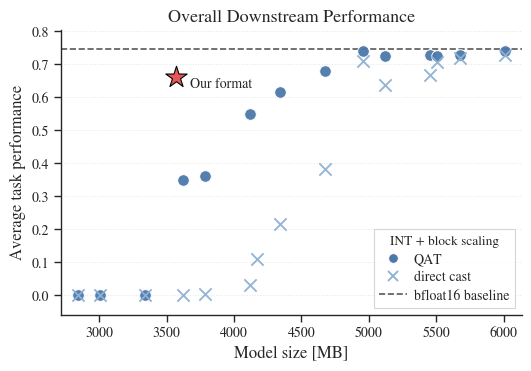

In [13]:
# NOTE: ICML-style presentation pass for the overall plot
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

fig, ax = plt.subplots(figsize=(5.2, 3.6), constrained_layout=True)

qat_color = "#4C78A8"
direct_cast_color = "#8FB1D4"
qat_df = baseline_df.loc[baseline_df["n_steps"] == 2048]
direct_cast_df = baseline_df.loc[baseline_df["n_steps"] == 0]
other_int_df = baseline_df.loc[~baseline_df["n_steps"].isin([0, 2048])]

ax.scatter(
    qat_df["size"],
    qat_df["overall"],
    s=70,
    color=qat_color,
    edgecolor="white",
    linewidth=0.7,
    alpha=0.95,
    zorder=3,
)

if not other_int_df.empty:
    ax.scatter(
        other_int_df["size"],
        other_int_df["overall"],
        s=70,
        color=qat_color,
        edgecolor="white",
        linewidth=0.7,
        alpha=0.95,
        zorder=3,
    )

ax.scatter(
    direct_cast_df["size"],
    direct_cast_df["overall"],
    s=78,
    marker="x",
    color=direct_cast_color,
    linewidth=1.35,
    alpha=0.95,
    zorder=4,
)

ax.axhline(
    baseline["overall"],
    linestyle="--",
    linewidth=1.2,
    color="0.35",
    label="bfloat16 baseline",
)
ax.scatter(
    [our_size],
    [our_perf],
    marker="*",
    s=260,
    color="#E45756",
    edgecolor="black",
    linewidth=0.8,
    zorder=10,
)

ax.annotate(
    "Our format",
    xy=(our_size, our_perf),
    xytext=(10, -10),
    textcoords="offset points",
    fontsize=10,
    ha="left",
    va="bottom",
)

ax.set_title("Overall Downstream Performance")
ax.set_xlabel("Model size [MB]")
ax.set_ylabel("Average task performance")
ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.5)
ax.margins(x=0.04, y=0.08)
sns.despine(ax=ax)

main_handles = [
    plt.Line2D(
        [], [], marker="o", linestyle="", markersize=7, markerfacecolor=qat_color,
        markeredgecolor="white", markeredgewidth=0.7, label="QAT"
    ),
    plt.Line2D(
        [], [], marker="x", linestyle="", markersize=7.5, color=direct_cast_color,
        markeredgewidth=1.35, label="direct cast"
    ),
    plt.Line2D([], [], linestyle="--", linewidth=1.2, color="0.35", label="bfloat16 baseline"),
]
ax.legend(
    handles=main_handles,
    title="INT + block scaling",
    loc="lower right",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    labelspacing=0.35,
    handletextpad=0.5,
)

# Save as vector art for cleaner inclusion in LaTeX if needed.
# fig.savefig(FIG_PATH / "fig1.pdf", bbox_inches="tight")

plt.show()

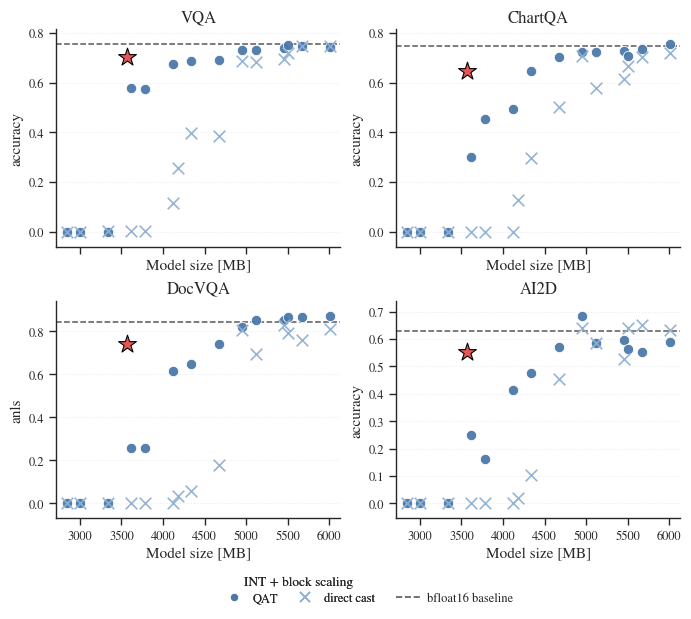

In [14]:
# NOTE: ICML-style presentation pass for the per-task plots
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

our_task_scores = {
    "vqa": best_run["vqa"],
    "chartqa": best_run["chartqa"],
    "docvqa": best_run["docvqa"],
    "ai2d": best_run["ai2d"],
}

qat_color = "#4C78A8"
direct_cast_color = "#8FB1D4"
qat_df = baseline_df.loc[baseline_df["n_steps"] == 2048]
direct_cast_df = baseline_df.loc[baseline_df["n_steps"] == 0]
other_int_df = baseline_df.loc[~baseline_df["n_steps"].isin([0, 2048])]

fig, axes = plt.subplots(2, 2, figsize=(6.8, 5.6), sharex=True, constrained_layout=True)
axes = axes.flatten()
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
task_titles = {
    "vqa": "VQA",
    "chartqa": "ChartQA",
    "docvqa": "DocVQA",
    "ai2d": "AI2D",
}

for ax, task in zip(axes, tasks):
    ax.scatter(
        qat_df["size"],
        qat_df[task],
        s=55,
        color=qat_color,
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
        zorder=3,
    )

    if not other_int_df.empty:
        ax.scatter(
            other_int_df["size"],
            other_int_df[task],
            s=55,
            color=qat_color,
            edgecolor="white",
            linewidth=0.6,
            alpha=0.95,
            zorder=3,
        )

    ax.scatter(
        direct_cast_df["size"],
        direct_cast_df[task],
        s=70,
        marker="x",
        color=direct_cast_color,
        linewidth=1.2,
        alpha=0.95,
        zorder=4,
    )

    ax.axhline(baseline[task], linestyle="--", linewidth=1.1, color="0.35")

    if our_task_scores is not None:
        ax.scatter(
            [our_size],
            [our_task_scores[task]],
            marker="*",
            s=180,
            color="#E45756",
            edgecolor="black",
            linewidth=0.8,
            zorder=10,
        )

    ax.set_title(task_titles[task])
    ax.set_xlabel("Model size [MB]")
    ax.set_ylabel(get_metric(task))
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.45)
    ax.margins(x=0.04, y=0.08)
    sns.despine(ax=ax)

int_handles = [
    plt.Line2D(
        [], [], marker="o", linestyle="", markersize=6, markerfacecolor=qat_color,
        markeredgecolor="white", markeredgewidth=0.6, label="QAT"
    ),
    plt.Line2D(
        [], [], marker="x", linestyle="", markersize=6.5, color=direct_cast_color,
        markeredgewidth=1.2, label="direct cast"
    ),
]
baseline_handles = [
    plt.Line2D([], [], linestyle="--", color="0.35", label="bfloat16 baseline"),
]

int_legend = fig.legend(
    handles=int_handles,
    title="INT + block scaling",
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.43, -0.09),
    columnspacing=1.2,
    labelspacing=0.35,
    handletextpad=0.5,
)
fig.add_artist(int_legend)
fig.legend(
    handles=baseline_handles,
    loc="lower center",
    ncol=1,
    frameon=False,
    bbox_to_anchor=(0.66, -0.09),
    handletextpad=0.5,
)

# Save as vector art for cleaner inclusion in LaTeX if needed.
# fig.savefig(FIG_PATH / "fig_tasks.pdf", bbox_inches="tight")

plt.show()


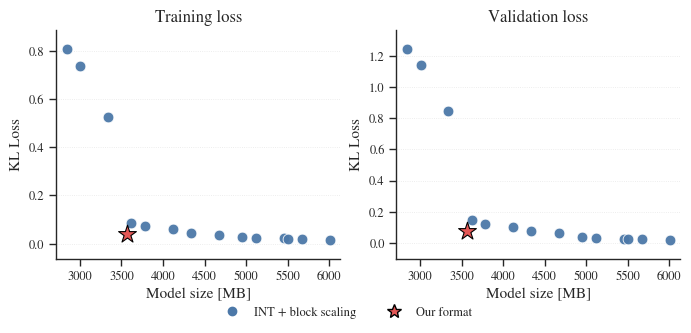

In [15]:
# NOTE: ICML-style presentation pass for the loss plots
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "STIXGeneral",
        "mathtext.fontset": "stix",
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

loss_specs = [
    ("train_loss", "Training loss"),
    ("val_loss", "Validation loss"),
]

our_loss_scores = {
    "train_loss": best_run["train_loss"],
    "val_loss": best_run["val_loss"],
}

fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.0), constrained_layout=True)

for ax, (key, title) in zip(axes, loss_specs):
    panel_df = baseline_df.dropna(subset=[key])
    sns.scatterplot(
        data=panel_df,
        x="size",
        y=key,
        ax=ax,
        s=60,
        color="#4C78A8",
        edgecolor="white",
        linewidth=0.6,
        alpha=0.95,
    )

    if our_loss_scores is not None:
        ax.scatter(
            [our_size],
            [our_loss_scores[key]],
            marker="*",
            s=180,
            color="#E45756",
            edgecolor="black",
            linewidth=0.8,
            zorder=10,
        )

    ax.set_title(title)
    ax.set_xlabel("Model size [MB]")
    ax.set_ylabel("KL Loss")
    ax.grid(axis="y", linestyle=":", linewidth=0.6, alpha=0.45)
    ax.margins(x=0.04, y=0.10)
    sns.despine(ax=ax)

handles = [
    plt.Line2D([], [], marker="o", linestyle="", markersize=6, color="#4C78A8", label="INT + block scaling"),
]
if our_loss_scores is not None:
    handles.append(
        plt.Line2D([], [], marker="*", linestyle="", markersize=10, color="#E45756", markeredgecolor="black", label="Our format")
    )
fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.08))

# Save as vector art for cleaner inclusion in LaTeX if needed.
# fig.savefig(FIG_PATH / "fig_loss.pdf", bbox_inches="tight")

plt.show()
